In [205]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [206]:
df=pd.read_csv('/content/mymoviedb.csv',lineterminator='\n')

#HAVING A LOOK AT THE DATA !!

In [207]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [208]:
df['Genre'].head()

,Genre
0,"Action, Adventure, Science Fiction"
1,"Crime, Mystery, Thriller"
2,Thriller
3,"Animation, Comedy, Family, Fantasy"
4,"Action, Adventure, Thriller, War"


In [209]:
df.duplicated().sum()

np.int64(0)

In [210]:
df.shape

(9827, 9)

In [211]:
df.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


#DATA PREPROCESSING

#CHANGING SYNTAX OF DATES:

In the release date column whole date like YY-MM-DD is given but that much of data is not required so we'll only care about the year .


In [212]:
df['Release_Date']=pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtypes)

datetime64[ns]


In [213]:
df['Release_Date']=df['Release_Date'].dt.year
df['Release_Date'].dtypes

dtype('int32')

In [214]:
df['Release_Date'].head()

,Release_Date
0,2021
1,2022
2,2022
3,2021
4,2021


#DROPING THE COLUMNS( which we don't need )

In [215]:
cols=['Overview','Poster_Url','Original_Language']

In [216]:
df.drop(cols,axis=1,inplace=True)

In [217]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


#CATEGORISING Vote_Average COLUMN
We would be diving this column into 4 different columns:Popular, Average, Below_Avg, Not_popular. Using Categorize_col() function.

In [218]:
def categorize_col(df,col,labels):
  edges=[df[col].describe()['min'],
         df[col].describe()['25%'],
         df[col].describe()['50%'],
         df[col].describe()['75%'],
         df[col].describe()['max']]
  df[col]=pd.cut(df[col],edges,labels=labels,duplicates='drop')
  return df

In [219]:
labels=['Not_popular','Below_avg','Average','Popular']
categorize_col(df,'Vote_Average',labels)
df['Vote_Average'].unique()


['Popular', 'Below_avg', 'Average', 'Not_popular', NaN]
Categories (4, object): ['Not_popular' < 'Below_avg' < 'Average' < 'Popular']

In [220]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_avg,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


In [221]:
df['Vote_Average'].value_counts()

,count
Vote_Average,
Not_popular,2467
Popular,2450
Average,2412
Below_avg,2398


In [222]:
df.dropna(inplace=True)
df.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


In [223]:
df.shape #shape has now become less

(9727, 6)

In [224]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,Popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,Below_avg,Thriller
3,2021,Encanto,2402.201,5076,Popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,Average,"Action, Adventure, Thriller, War"


#Now I have sperated the genre of one movie into multiple columns so that its becomes easy to analyse

In [225]:
df['Genre'] = df['Genre'].str.split(',')
df = df.explode('Genre').reset_index(drop=True)

# remove leading/trailing spaces
df['Genre'] = df['Genre'].str.strip()

In [226]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


In [227]:
#Casting columns into category
df['Genre']=df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [228]:
df.shape    # data increased from 9,827 to 25,552

(25552, 6)

In [229]:
df.nunique()

,0
Release_Date,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19


#Data Visualization

In [230]:
sns.set_style('whitegrid')

#What's most frequent genre of movie on netflix ?

In [231]:
df['Genre'].describe()   #Drama comes out to have max frequency

,Genre
count,25552
unique,19
top,Drama
freq,3715


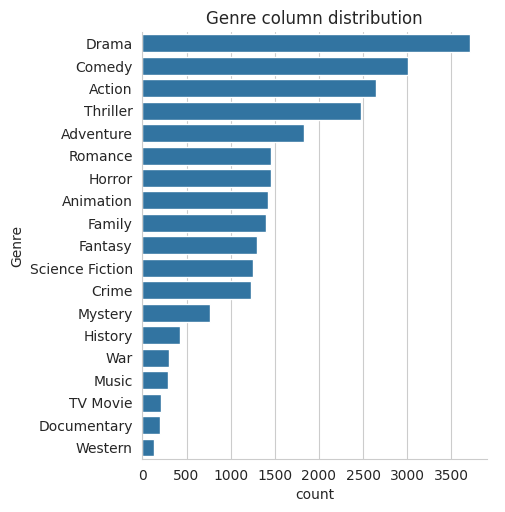

In [232]:
sns.catplot(y='Genre',data=df,kind='count',
            order=df['Genre'].value_counts().index)
plt.title("Genre column distribution")
plt.show()

#Which has highest votes in Vote_avg column

In [233]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction
3,2022,The Batman,3827.658,1151,Popular,Crime
4,2022,The Batman,3827.658,1151,Popular,Mystery


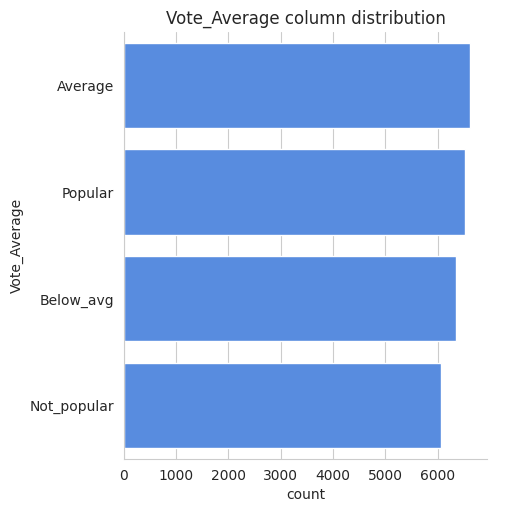

In [234]:
sns.catplot(y='Vote_Average',data=df,kind='count',
            order=df['Vote_Average'].value_counts().index,
            color='#4287f5')
plt.title("Vote_Average column distribution")
plt.show()

#What movie got the highest popularity ? What's its genre ?

In [235]:
df.loc[df['Popularity'].idxmax()]

,0
Release_Date,2021
Title,Spider-Man: No Way Home
Popularity,5083.954
Vote_Count,8940
Vote_Average,Popular
Genre,Action


In [236]:
df[df['Popularity']==df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,Popular,Science Fiction


#What movie got the lowest popularity ? What's its genre ?

In [237]:
df.loc[df['Popularity'].idxmin()]

,25546
Release_Date,2021
Title,The United States vs. Billie Holiday
Popularity,13.354
Vote_Count,152
Vote_Average,Average
Genre,Music


In [238]:
df[df['Popularity']==df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,2021,The United States vs. Billie Holiday,13.354,152,Average,Music
25547,2021,The United States vs. Billie Holiday,13.354,152,Average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,Average,History
25549,1984,Threads,13.354,186,Popular,War
25550,1984,Threads,13.354,186,Popular,Drama
25551,1984,Threads,13.354,186,Popular,Science Fiction


#Which year has most filmed movies ?

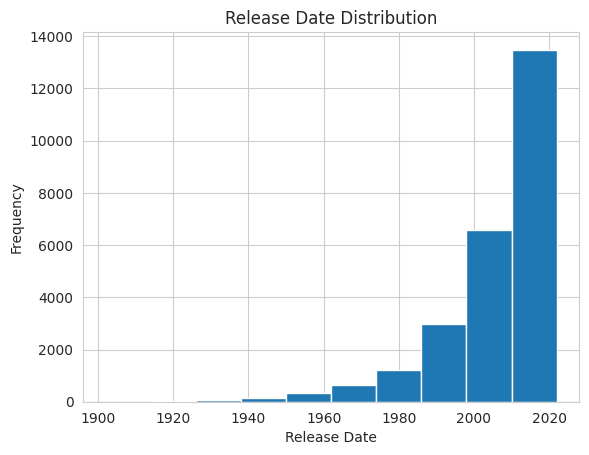

In [239]:
df['Release_Date'].hist()
plt.title('Release Date Distribution')
plt.xlabel('Release Date')
plt.ylabel('Frequency')
plt.show()

#Correlation Heatmap

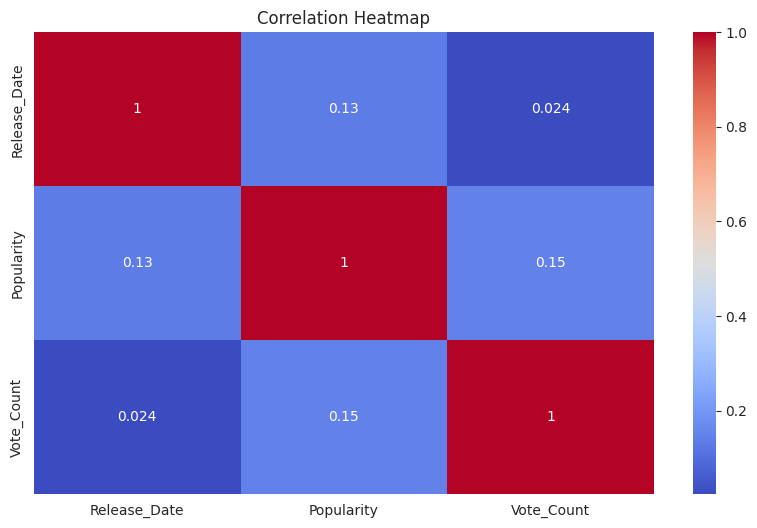

In [240]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#Top 10 most popular movies

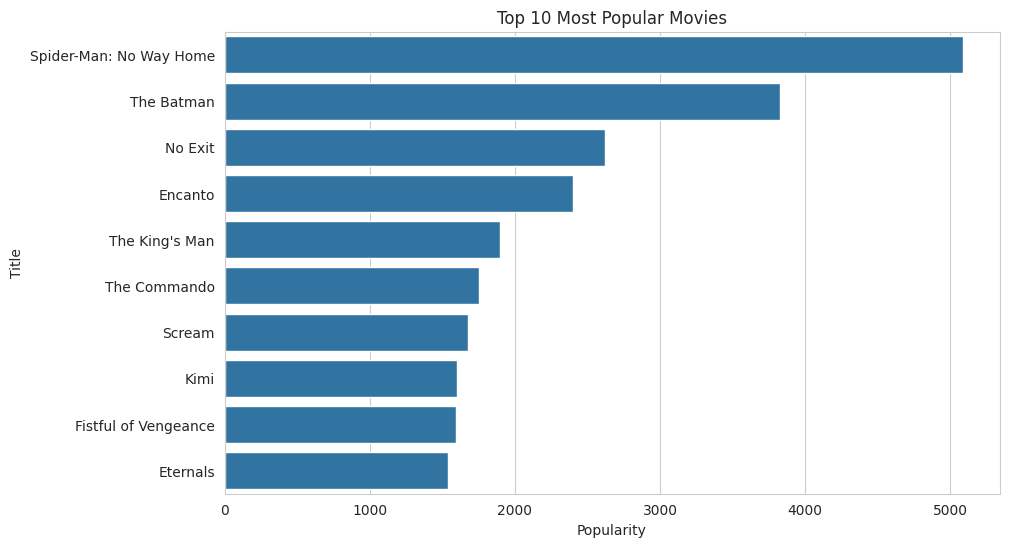

In [241]:
top_movies = (
    df[['Title','Popularity']]
    .drop_duplicates()
    .sort_values('Popularity', ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_movies,
    x='Popularity',
    y='Title'
)

plt.title('Top 10 Most Popular Movies')
plt.show()

In [242]:
print(top_movies.shape)
top_movies[['Title','Popularity']]

(10, 2)


,Title,Popularity
0,Spider-Man: No Way Home,5083.954
3,The Batman,3827.658
6,No Exit,2618.087
7,Encanto,2402.201
11,The King's Man,1895.511
15,The Commando,1750.484
18,Scream,1675.161
21,Kimi,1601.782
22,Fistful of Vengeance,1594.013
25,Eternals,1537.406


 Conclusion :

Q1. What's most frequent genre of movie on netflix ?  

Ans. Drama

Q2. Which has highest votes in Vote_avg column ?

Ans. Average types of movies

Q3. What movie got the highest popularity ? What's its genre ?

Ans. Spider-Man: No Way Home

Q4. What movie got the lowest popularity ? What's its genre ?

Ans. The United States vs. Billie Holiday and Threads

Q5. Which year has most filmed movies ?

Ans. 2020's